In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.callbacks import EarlyStopping
import keras_tuner as kt

c:\Users\Kim_W\BI_Assignment\BI_env\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


# Predicting weather a flight will arrive more than 15 minutes late

In [2]:
data_1993 = pd.read_csv('data_1993_2.csv', low_memory = False)
data_1993

,Unnamed: 0,CRSElapsedTime,DepDelay,Origin,Dest,Distance,time_of_day_CRSDepTime,time_of_day_CRSArrTime,Weekend,Season,Delay
0,0,77,0.0,EWR,BUF,282.0,2,3,0,1,1
1,1,77,-3.0,EWR,BUF,282.0,2,3,1,1,0
2,2,77,8.0,EWR,BUF,282.0,2,3,1,1,0
3,3,131,8.0,MCO,PIT,834.0,3,4,0,1,0
4,4,131,7.0,MCO,PIT,834.0,3,4,1,1,0
...,...,...,...,...,...,...,...,...,...,...,...
2105417,2105417,60,-3.0,EWR,BWI,169.0,2,2,0,1,0
2105418,2105418,60,0.0,EWR,BWI,169.0,2,2,0,1,0
2105419,2105419,60,3.0,EWR,BWI,169.0,2,2,0,1,0
2105420,2105420,60,-4.0,EWR,BWI,169.0,2,2,0,1,0


In [3]:
data_1993 = data_1993.drop(['Unnamed: 0'], axis=1)

Text(0.5, 1.0, 'Correlation Matrix Heatmap')

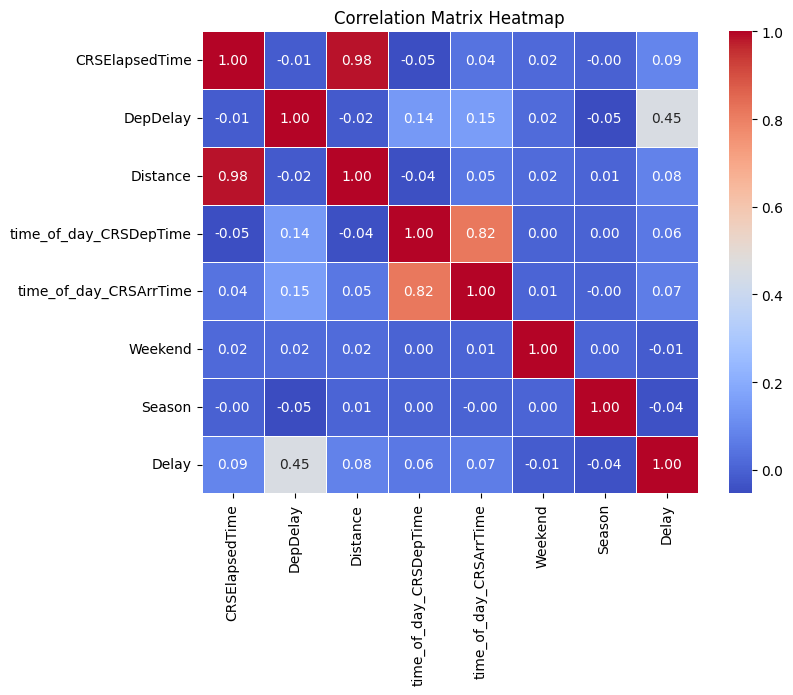

In [4]:
plt.figure(figsize=(8, 6))
corr = data_1993[['CRSElapsedTime',	'DepDelay',	'Distance',	'time_of_day_CRSDepTime',	'time_of_day_CRSArrTime',	'Weekend',	'Season',	'Delay']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix Heatmap')

## 1. Training, Test & Validation Set

nodelay_counts = len(data_1993[data_1993['Delay'] == 0])
delay_counts = len(data_1993[data_1993['Delay'] == 1])

counts = nodelay_counts - delay_counts

print(counts)

target_column = 'Delay'   # Column to check
target_value = 0           # Value to match
remove_count = counts             # Number of rows to randomly remove

# Filter rows matching the condition
matching_rows = data_1993[data_1993[target_column] == target_value]

# Randomly select rows to drop
rows_to_drop = matching_rows.sample(n=remove_count, random_state=42).index

# Drop the selected rows
data_1993 = data_1993.drop(index=rows_to_drop).reset_index(drop=True)

print("\nDataFrame after removing rows:")
print(data_1993['Delay'].value_counts())

In [5]:
X_1993 = data_1993.drop(columns = ['Delay', 'Weekend', 'Season'], axis=1)
y_1993 = data_1993['Delay']

In [6]:
categorical_cols_1993 = X_1993.select_dtypes(include='object').columns

numerical_cols_1993 = X_1993.select_dtypes(exclude='object').columns

In [7]:
X_1993_categorical_encoded = pd.get_dummies(X_1993[categorical_cols_1993], drop_first=True, dummy_na=False)

X_1993_processed = pd.concat([X_1993[numerical_cols_1993], X_1993_categorical_encoded], axis=1)

In [8]:
Scaler_1993 = StandardScaler()
X_1993_scaled = Scaler_1993.fit_transform(X_1993_processed)

In [9]:
X_train_1993, X_temp_1993, y_train_1993, y_temp_1993 = train_test_split(X_1993_scaled, y_1993, test_size=0.30, random_state=42, stratify=y_1993)
X_val_1993, X_test_1993, y_val_1993, y_test_1993 = train_test_split(X_temp_1993, y_temp_1993, test_size=0.50, random_state=42, stratify=y_temp_1993)

In [10]:
print("Data_1993 preparation and splitting complete.")
print(f"X_train_1993 shape: {X_train_1993.shape}")
print(f"X_val_1993 shape: {X_val_1993.shape}")
print(f"X_test_1993 shape: {X_test_1993.shape}")
print(f"y_train_1993 shape: {y_train_1993.shape}")
print(f"y_val_1993 shape: {y_val_1993.shape}")
print(f"y_test_1993 shape: {y_test_1993.shape}")

Data_1993 preparation and splitting complete.
X_train_1993 shape: (1473795, 457)
X_val_1993 shape: (315813, 457)
X_test_1993 shape: (315814, 457)
y_train_1993 shape: (1473795,)
y_val_1993 shape: (315813,)
y_test_1993 shape: (315814,)


## 2. Model Generation

In [11]:
def create_nn_model(input_shape):
    
    Dense = tf.keras.layers.Dense
    Dropout = tf.keras.layers.Dropout
        
    model = tf.keras.Sequential()
    model.add(keras.layers.Input(shape=(input_shape,)))
    model.add(Dense(units=128, activation='relu'))
    model.add(Dense(units=64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
    return model

In [12]:
input_shape_1993 = X_train_1993.shape[1]

## 3. Fitting Model

In [13]:
early_stopping = EarlyStopping(monitor='val_loss', patience= 5, restore_best_weights = True)

In [19]:
#model_1993 = tuner.hypermodel.build(best_hp)
model_1993 = create_nn_model(input_shape_1993)
model_1993.fit(X_train_1993, y_train_1993, epochs=10, batch_size=32, validation_data=(X_val_1993, y_val_1993), callbacks=[early_stopping])

Epoch 1/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 202s 4ms/step - accuracy: 0.8156 - loss: 0.4347 - val_accuracy: 0.8169 - val_loss: 0.4297
Epoch 2/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 139s 3ms/step - accuracy: 0.8181 - loss: 0.4276 - val_accuracy: 0.8176 - val_loss: 0.4288
Epoch 3/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 156s 3ms/step - accuracy: 0.8188 - loss: 0.4259 - val_accuracy: 0.8175 - val_loss: 0.4271
Epoch 4/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 133s 3ms/step - accuracy: 0.8193 - loss: 0.4249 - val_accuracy: 0.8185 - val_loss: 0.4263
Epoch 5/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 214s 5ms/step - accuracy: 0.8197 - loss: 0.4239 - val_accuracy: 0.8190 - val_loss: 0.4253
Epoch 6/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 251s 5ms/step - accuracy: 0.8200 - loss: 0.4235 - val_accuracy: 0.8193 - val_loss: 0.4246
Epoch 7/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 201s 4ms/step - accuracy: 0.8201 - loss: 0.4230 - val_accuracy: 0.8189 - val_loss: 0.4245
Epoch 8/10
46057/46057 ━━━━━━━━━━━━━━━━━━━━ 92s 2ms/step - acc

## 4. Model Evaluation

In [20]:
loss_1993, accuracy_1993 = model_1993.evaluate(X_test_1993, y_test_1993)
print(f"Test Loss for 1993 model: {loss_1993:.4f}")
print(f"Test Accuracy for 1993 model: {accuracy_1993:.4f}")

9870/9870 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.8191 - loss: 0.4238
Test Loss for 1993 model: 0.4238
Test Accuracy for 1993 model: 0.8191


9870/9870 ━━━━━━━━━━━━━━━━━━━━ 8s 831us/step


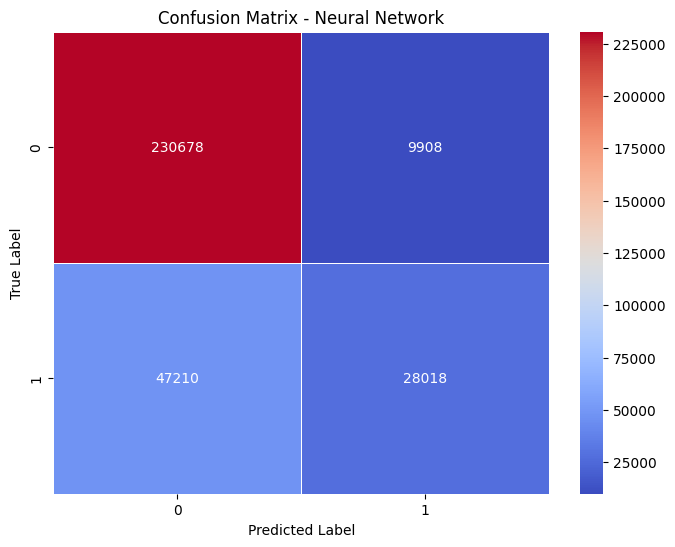

In [21]:
import numpy as np
from sklearn.metrics import confusion_matrix
y_pred_probs = model_1993.predict(X_test_1993)
y_pred = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test_1993, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, cmap='coolwarm', fmt='d', linewidths=0.5)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Neural Network")
plt.show()

In [22]:
model_1993.save("1993_model_base.h5")